# 01 — Exploración de Datos: Health Insurance Cross Sell

**Reto 2 — IA avanzada en Business Analytics | Odisea Data**

**Objetivo:** Comprender la estructura del dataset, identificar variables clave, analizar la distribución de la variable objetivo y detectar problemas como valores nulos o desbalanceo de clases.

**Dataset:** 381.109 clientes con seguro de salud. Variable objetivo: `Response` (interés en contratar seguro de vehículo).

In [2]:
# ============================================================
# IMPORTS Y CONFIGURACIÓN
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Estilo de gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Pandas: mostrar todas las columnas
pd.set_option("display.max_columns", None)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


In [3]:
# ============================================================
# CARGA DEL DATASET
# ============================================================
# Si lo subiste manualmente:
df = pd.read_csv("/content/train.csv")

# Si usaste la API de Kaggle, la ruta sería:
# df = pd.read_csv("train.csv")

print(f"📊 Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

📊 Dimensiones del dataset: 381,109 filas × 12 columnas


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [4]:
# ============================================================
# INFORMACIÓN GENERAL
# ============================================================
print("=" * 60)
print("TIPOS DE DATOS Y VALORES NO NULOS")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas")
print("=" * 60)
df.describe().T

print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS — Variables categóricas")
print("=" * 60)
df.describe(include=["object"]).T

TIPOS DE DATOS Y VALORES NO NULOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB

ESTADÍSTICAS DESCRIPTIVAS — Variables numéricas

ESTADÍSTICAS D

,count,unique,top,freq
Gender,381109,2,Male,206089
Vehicle_Age,381109,3,1-2 Year,200316
Vehicle_Damage,381109,2,Yes,192413


In [5]:
# ============================================================
# VALORES NULOS Y DUPLICADOS
# ============================================================
print("=" * 60)
print("VALORES NULOS")
print("=" * 60)
nulos = df.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ No hay valores nulos")

print("\n" + "=" * 60)
print("DUPLICADOS")
print("=" * 60)
dup = df.duplicated().sum()
print(f"Filas duplicadas: {dup}" if dup > 0 else "✅ No hay filas duplicadas")

VALORES NULOS
✅ No hay valores nulos

DUPLICADOS
✅ No hay filas duplicadas


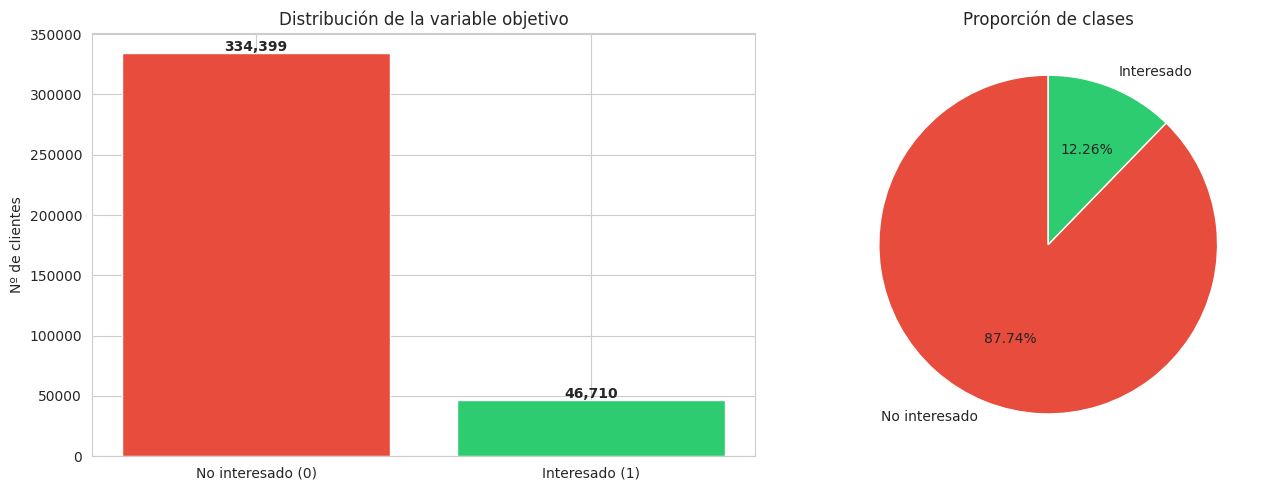


📊 Ratio de desbalanceo: 7.16:1 (no interesados : interesados)


In [6]:
# ============================================================
# ANÁLISIS DE LA VARIABLE OBJETIVO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
counts = df["Response"].value_counts()
axes[0].bar(["No interesado (0)", "Interesado (1)"], counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Distribución de la variable objetivo")
axes[0].set_ylabel("Nº de clientes")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f"{v:,}", ha="center", fontweight="bold")

# Porcentaje
axes[1].pie(counts.values, labels=["No interesado", "Interesado"],
            autopct="%1.2f%%", colors=["#e74c3c", "#2ecc71"], startangle=90)
axes[1].set_title("Proporción de clases")

plt.tight_layout()
plt.savefig("target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n📊 Ratio de desbalanceo: {counts[0]/counts[1]:.2f}:1 (no interesados : interesados)")

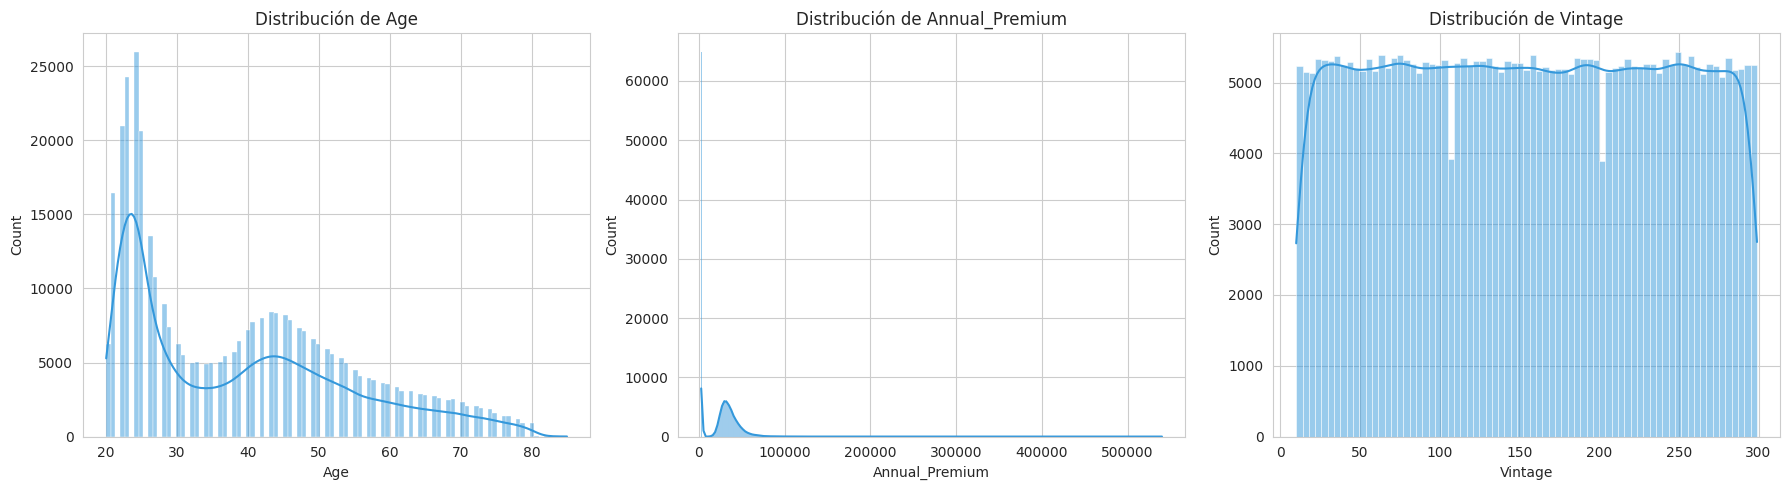

In [7]:
# ============================================================
# DISTRIBUCIÓN DE VARIABLES NUMÉRICAS
# ============================================================
num_cols = ["Age", "Annual_Premium", "Vintage"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#3498db")
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel(col)

plt.tight_layout()
plt.savefig("num_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

ValueError: Could not interpret value `PolicySalesChannel` for `x`. An entry with this name does not appear in `data`.

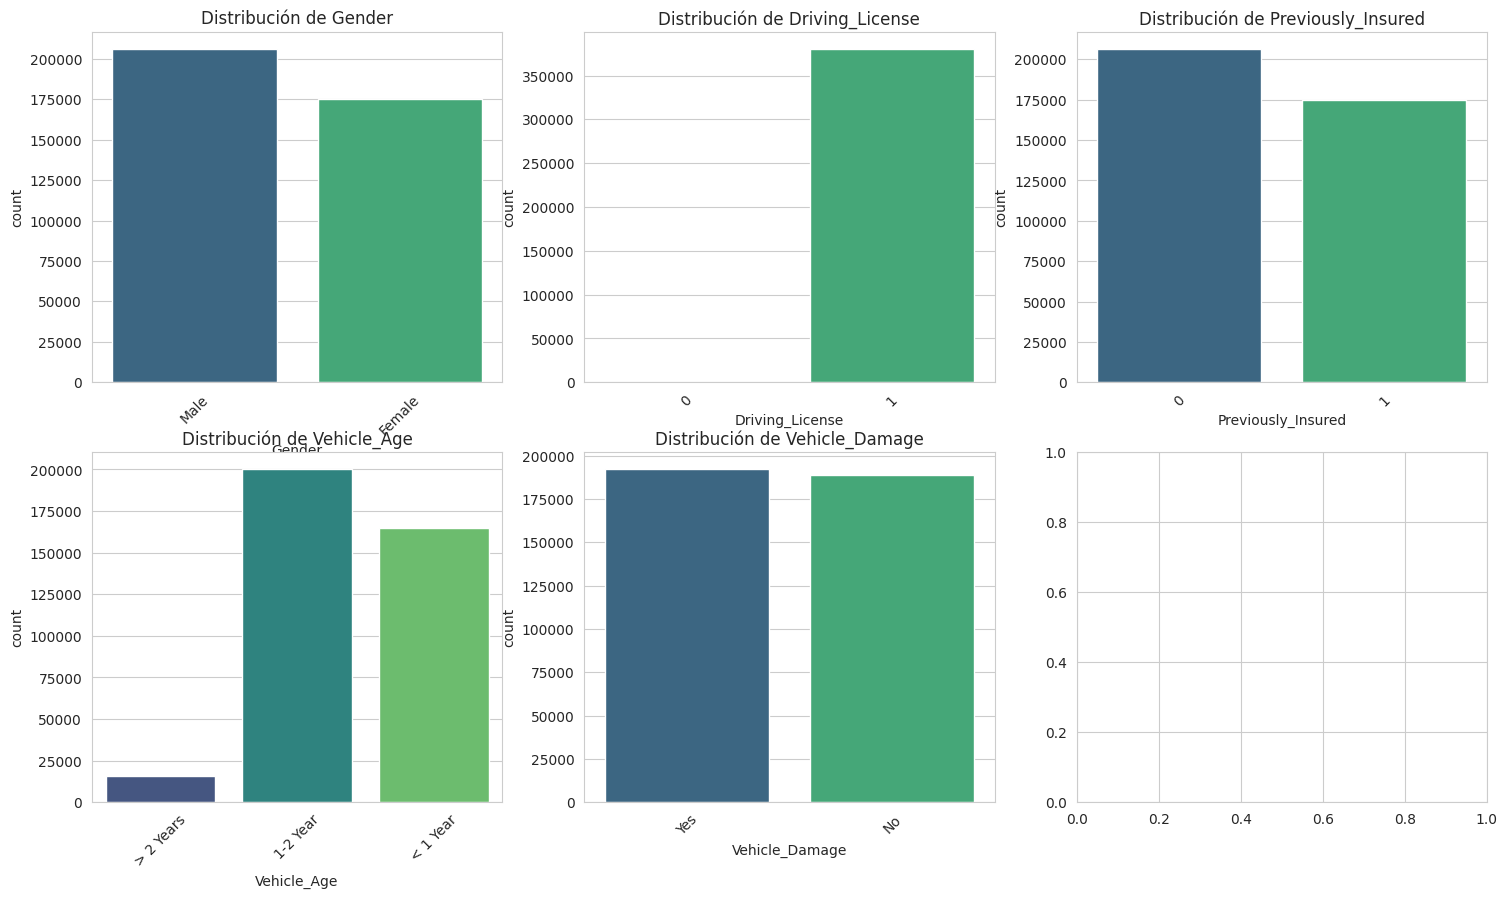

In [8]:
# ============================================================
# DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS
# ============================================================
cat_cols = ["Gender", "Driving_License", "Previously_Insured",
            "Vehicle_Age", "Vehicle_Damage", "PolicySalesChannel"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, ax=ax, palette="viridis")
    ax.set_title(f"Distribución de {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("cat_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

ValueError: Could not interpret value `PolicySalesChannel` for `x`. An entry with this name does not appear in `data`.

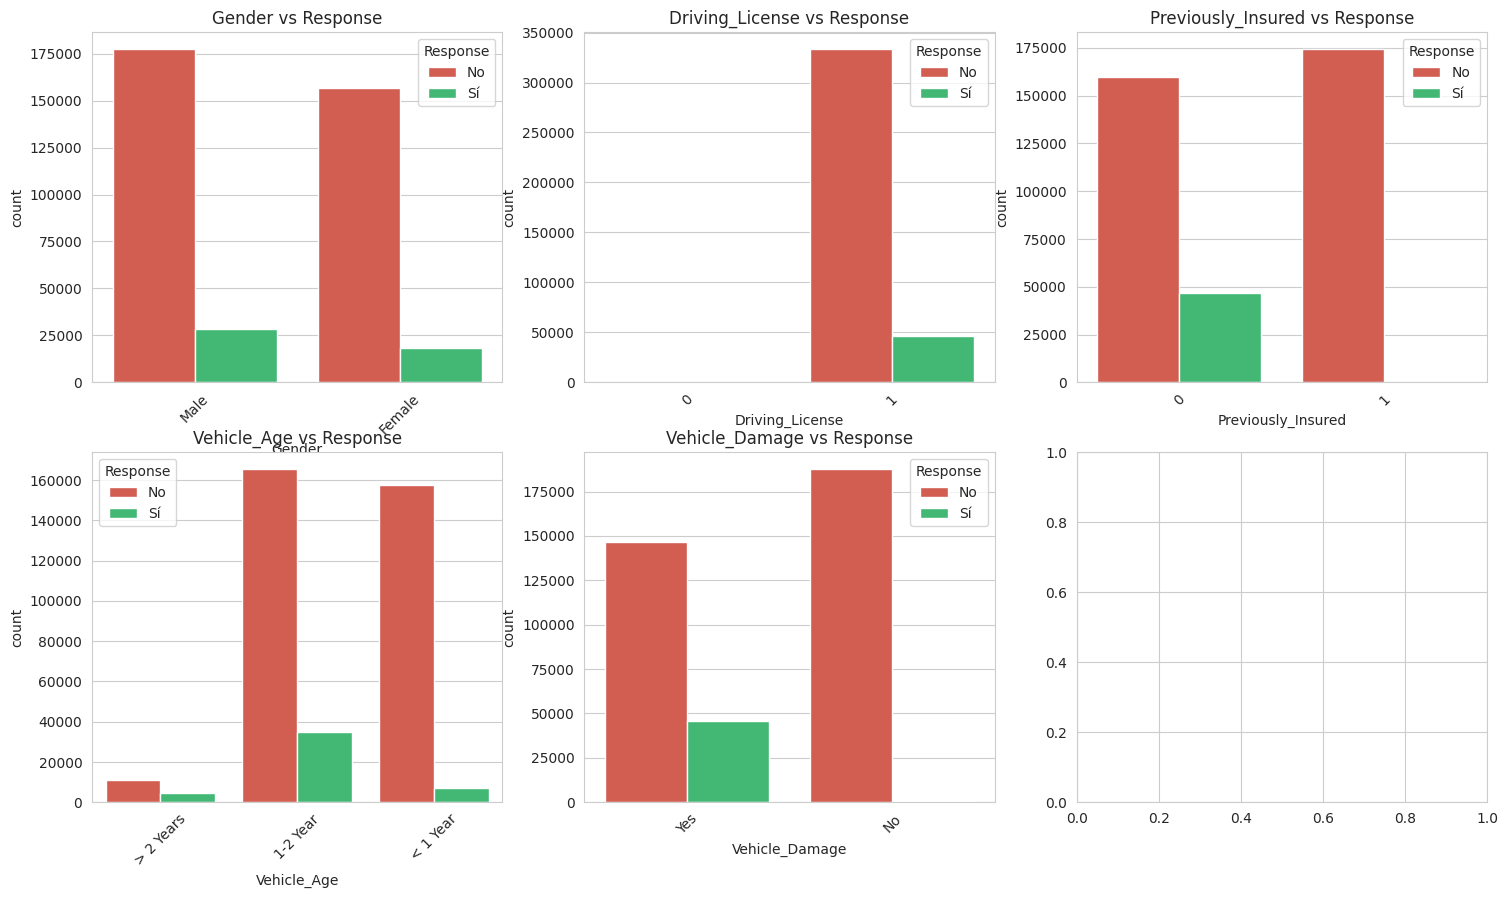

In [9]:
# ============================================================
# ANÁLISIS BIVARIANTE: variables categóricas vs Response
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue="Response", ax=ax, palette=["#e74c3c", "#2ecc71"])
    ax.set_title(f"{col} vs Response")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Response", labels=["No", "Sí"])

plt.tight_layout()
plt.savefig("bivariate_cat.png", dpi=150, bbox_inches="tight")
plt.show()

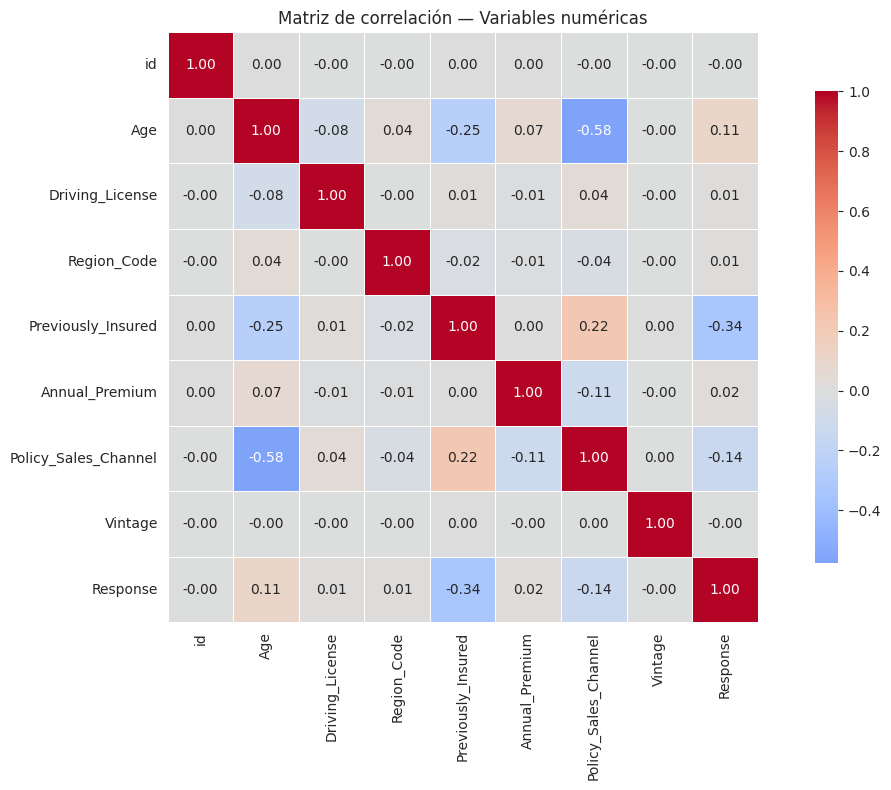

In [10]:
# ============================================================
# MATRIZ DE CORRELACIÓN
# ============================================================
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlación — Variables numéricas")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 🔍 Conclusiones de la Exploración

### Estructura del dataset
- **381.109 filas** × **12 columnas**.
- Sin valores nulos ni duplicados.
- 1 variable objetivo binaria (`Response`) + 11 predictoras.

### Problemas detectados
- ⚠️ **Fuerte desbalanceo de clases:** ~87% no interesados vs ~13% interesados.
  Esto condiciona la elección de métricas (usaremos **F1, Recall y AUC-ROC**, no accuracy).

### Variables clave (hipótesis iniciales)
- **`Previously_Insured`** → los que ya tienen seguro de vehículo muestran interés casi nulo.
- **`Vehicle_Damage`** → los que han sufrido daños tienen mucha más propensión.
- **`Age`** → los más jóvenes y los mayores muestran patrones diferenciados.
- **`Annual_Premium`** → distribución muy sesgada, requerirá tratamiento.

### Próximos pasos (notebook 02)
1. Codificación de variables categóricas (One-Hot / Label Encoding).
2. Tratamiento de outliers en `Annual_Premium`.
3. Escalado de variables numéricas.
4. División train/test estratificada.
5. Guardado del dataset procesado en `data/processed/`.